# Deterministic Fatigue Model

This is the baseline physics model. It examines the **mechanics** of crack growth under **perfectly controlled** conditions.

Using,
- fixed stress amplitude, S
- fixed defect size, A
- fixed material constants, C, m, n

to compute:
- stress intensity factor, ΔK
- fatigue life, N

with,
- ΔK = S*sqrt(piA)
- the fatigue-life equations.

This model predicts a single fatigue life for a given defect and stress.

It includes:
- S–N curves
- effect of stress amplitude
- effect of defect size
- effect of Paris-law exponent m
- Shiozawa-style defect sensitivity plots

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Variables

In [2]:
# reference values for calibration
stress_ref = 100     # stress amplitude, [MPa]
A_ref = 100          # defect size, [mm^2]
N_ref = 1e5          # fatigue life, [cycles]

m = 2.7              # sensitivity to stress
n = 1.5              # sensitivity to defect size

# calibrate C given these values
C = N_ref * (stress_ref**m) * (A_ref**n)

In [3]:
# define variables
mu = 3              # mean of log
sigma = 1           # std dev of log
Y = 1.0             # geometry factor
n_defects = 1000    # size of random dataset

In [4]:
# define variables for sensitivity analysis
stress_vary = np.linspace(start=50, stop=500, num=n_defects)      # stress amplitude [MPa]
defect_vary = np.linspace(start=10, stop=100, num=n_defects)      # defect size [mm^2]

# define parameters for sensitivity analysis
m_vary = [2.0, 2.7, 3.5]     # sensitivity to stress
n_vary = [1.0, 1.5, 2.0]     # sensitivity to defect size
C_vals = [1e12, 5e12, 1e13]

# Data

Defect data is generated randomly based on lognormal distribution.

In [5]:
# define function to generate defects based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return np.random.lognormal(mu,           # mean of logarithm 
                               sigma,        # std dev
                               n_defects)    # no. of random samples generated

# generate n_defects random defects
defects = generate_defects(n_defects, mu, sigma)

# 1. Fatigue Life

In [6]:
# define function to find the fatigue life, N, based on the given parameters
def fatigue_life(stress_amp, defect_size, C, m, n):
    return C / ((stress_amp**m) * (defect_size**n))

## 1.1 S-N Curves
The stress amplitude, S, vs. the number of cycles, N, is plotted.

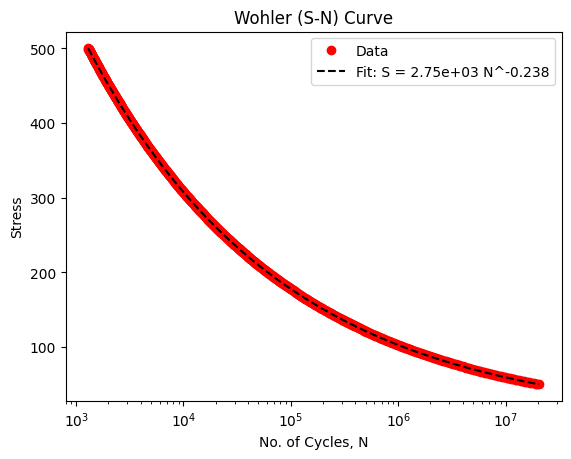

In [7]:
# data
N = fatigue_life(stress_vary, defect_vary, C, m, n)
S = stress_vary

# log transform
logN = np.log10(N)
logS = np.log10(S)

# linear fit: logS = b logN + loga
b, loga = np.polyfit(logN, logS, 1)
a = 10**loga

# fitted curve
N_line = np.logspace(np.log10(N.min()), np.log10(N.max()), 200)
S_line = a * N_line**b

# plot original
plt.plot(N, S, 'o', color='red', label='Data')

# plot fit
plt.plot(N_line, S_line, color='black', linestyle='--',
         label=f'Fit: S = {a:.2e} N^{b:.3f}')

plt.xscale('log')

plt.title('Wohler (S-N) Curve')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress')

plt.legend()

plt.show()

### 1.1.A Varying Stress
- fixed defect size
- vary stress

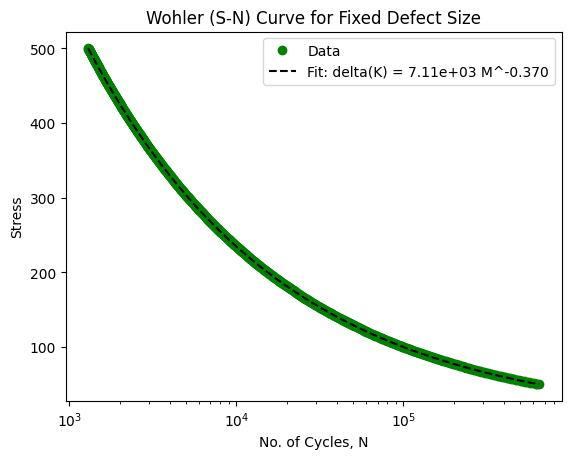

In [8]:
# define data
A_fixed = 100                                        # fixed defect size, A, [mm^2]
N = fatigue_life(stress_vary, A_fixed, C, m, n)      # no. of cycles, N, or fatigue life
S = stress_vary                                      # stress amplitude

# log transform
logN = np.log10(N)
logS = np.log10(S)

# linear fit: logS = b logN + loga
b, loga = np.polyfit(logN, logS, 1)
a = 10**loga

# fitted curve
N_line = np.logspace(np.log10(N.min()), np.log10(N.max()), 200)
S_line = a * N_line**b

# plot original
plt.plot(N, S, 'o', color='green', label='Data')

# plot fit
plt.plot(N_line, S_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} M^{b:.3f}')

plt.xscale('log')

plt.title('Wohler (S-N) Curve for Fixed Defect Size')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress')

plt.legend()

plt.show()

### 1.1.B Varying Defect Size
- fixed stress
- vary defect size

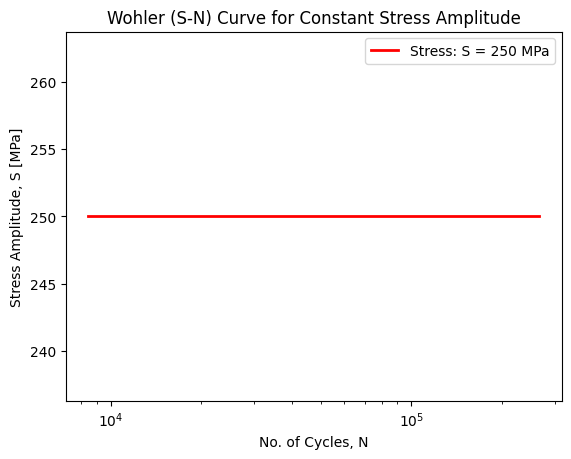

In [9]:
# define data
S_fixed = 250                                       # fixed stress amplitude, S, [MPa]
N = fatigue_life(S_fixed, defect_vary, C, m, n)     # no. of cycles, N, or fatigue life

S_array = np.full_like(N, S_fixed)

# create an S-N curve
plt.plot(N, S_array, color='red', linewidth=2, markersize=12,
         label='Stress: S = 250 MPa')

plt.xscale('log')

# axis labels
plt.title('Wohler (S-N) Curve for Constant Stress Amplitude')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress Amplitude, S [MPa]')

plt.legend()

plt.show()

### 1.1.C Defect Sensitivities
- fixed stress
- fixed defect size
- vary:
    - m
    - n
    - C

#### Varying m

In [10]:
# define fixed data
A_fixed = 100.0         # fixed defect size, A, [mm^2]
S_fixed = 250.0         # fixed stress amplitude, S, [MPa]

# calculate fatigue life, N, for each m
for m_i in m_vary:
    N = fatigue_life(S_fixed, A_fixed, C, m_i, n)     # no. of cycles, N, or fatigue life
    print(m_i, N)

2.0 401901.8290415331
2.7 8424.846107739117
3.5 101.67401404470812


##### Plot Curves for Varying m

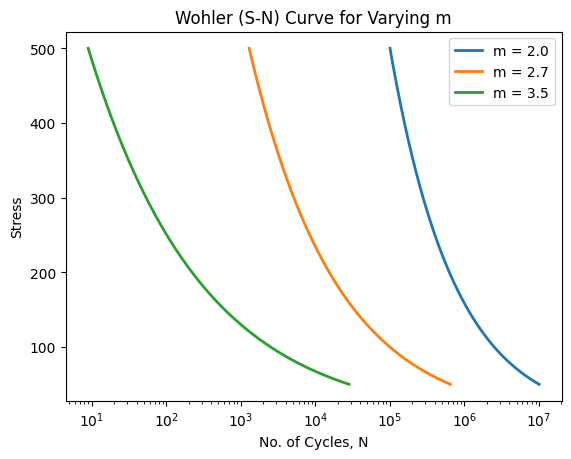

In [11]:
# calculate fatigue life, N, for each m
for m_i in m_vary:
    N = fatigue_life(stress_vary,       # varying stress amplitude, S, [MPa]
                     A_fixed,
                     C, m_i, n)
    plt.plot(N, stress_vary,
             linewidth=2,
             markersize=12,
             label=f'm = {m_i}')
    
plt.xscale('log')

# axis labels
plt.title('Wohler (S-N) Curve for Varying m')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress')

plt.legend()

plt.show()

#### Varying n

In [12]:
# define fixed data
A_fixed = 100.0         # fixed defect size, A, [mm^2]
S_fixed = 250.0         # fixed stress amplitude, S, [MPa]

# calculate fatigue life, N, for each n
for n_i in n_vary:
    N = fatigue_life(S_fixed, A_fixed, C, m, n_i)     # no. of cycles, N, or fatigue life
    print(n_i, N)

1.0 84248.46107739118
1.5 8424.846107739117
2.0 842.4846107739116


##### Plot Curves for Varying n

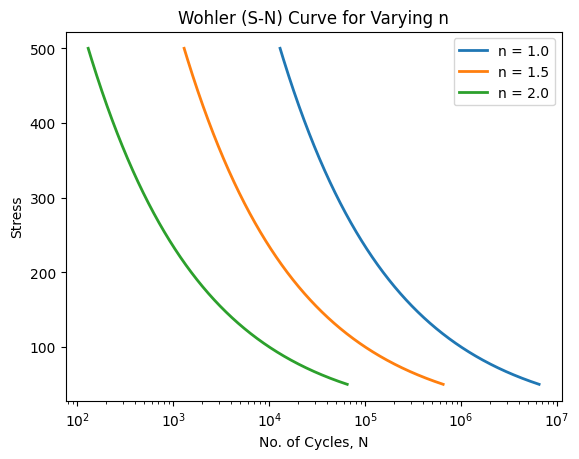

In [13]:
# calculate fatigue life, N, for each n
for n_i in n_vary:
    N = fatigue_life(stress_vary,       # varying stress amplitude, S, [MPa]
                     A_fixed,
                     C, m, n_i)
    plt.plot(N, stress_vary,
             linewidth=2,
             markersize=12,
             label=f'n = {n_i}')

plt.xscale('log')

# axis labels
plt.title('Wohler (S-N) Curve for Varying n')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress')

plt.legend()

plt.show()

#### Varying C

In [14]:
# define fixed data
A_fixed = 100.0         # fixed defect size, A, [mm^2]
S_fixed = 250.0         # fixed stress amplitude, S, [MPa]

# calculate fatigue life, N, for each C
for C_i in C_vals:
    N = fatigue_life(S_fixed, A_fixed, C_i, m, n)     # no. of cycles, N, or fatigue life
    print(C_i, N)

1000000000000.0 335.39916463006614
5000000000000.0 1676.9958231503308
10000000000000.0 3353.9916463006616


##### Plot Curves for Varying C

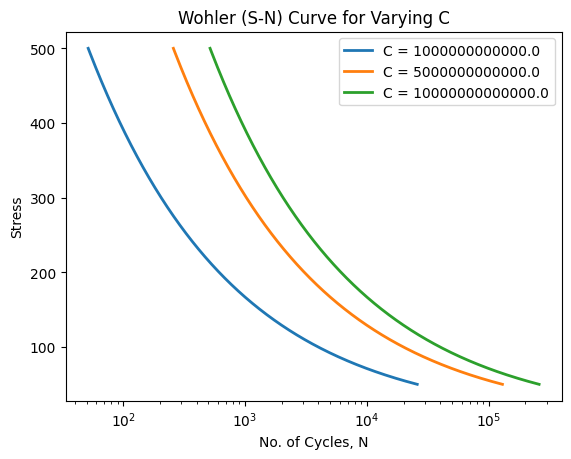

In [15]:
# calculate fatigue life, N, for each C
for C_i in C_vals:
    N = fatigue_life(stress_vary,       # varying stress amplitude, S, [MPa]
                     A_fixed,
                     C_i, m, n)
    plt.plot(N, stress_vary,
             linewidth=2,
             markersize=12,
             label=f'C = {C_i}')

plt.xscale('log')

# axis labels
plt.title('Wohler (S-N) Curve for Varying C')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress')

plt.legend()

plt.show()

# 2. Shiozawa Curves

## 2.1 Stress Intensity Factor

In [16]:
# define function to compute stress intensity factor, delta(K)
def stress_intensity_factor(stress_amp, defect_size):
    return Y * stress_amp * np.sqrt(np.pi * defect_size)

# calculate stress intensity factor, delta(K)
delta_K = stress_intensity_factor(stress_vary, defect_vary)

### 2.1.A Fixed Stress

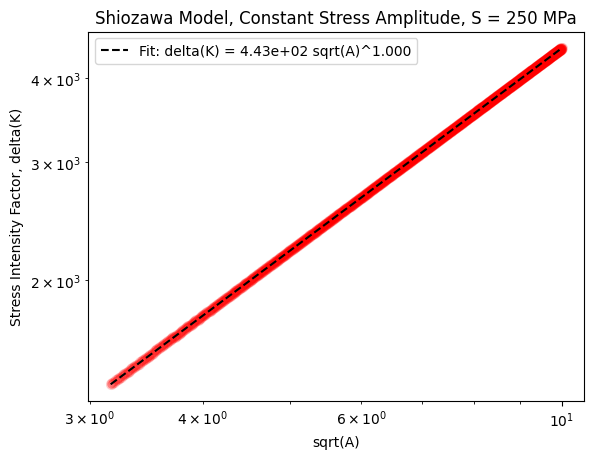

In [17]:
# data
S_fixed = 250                                       # fixed stress amplitude, S, [MPa]
sqrt_A = np.sqrt(defect_vary)                       # sqrt of defect size, sqrt(A), [mm^2]
delta_K = stress_intensity_factor(S_fixed, defect_vary)                                    # stress amplitude

# log transform
log_sqrt_A = np.log10(sqrt_A)
log_delta_K = np.log10(delta_K)

# linear fit: log_delta_K = b log_sqrt_A + loga
b, loga = np.polyfit(log_sqrt_A, log_delta_K, 1)
a = 10**loga

# fitted curve
sqrt_A_line = np.logspace(np.log10(sqrt_A.min()), np.log10(sqrt_A.max()), 200)
delta_K_line = a * sqrt_A_line**b

# scatter plot of delta(K) vs sqrt(A)
plt.scatter(np.sqrt(defect_vary), delta_K, alpha=0.2, color='red', linewidth=2)

# plot fit
plt.plot(sqrt_A_line, delta_K_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} sqrt(A)^{b:.3f}')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Model, Constant Stress Amplitude, S = 250 MPa')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend()

plt.show()

# Critical Defects

The critical defect is the one that leads to failure. Assume this is the largest defect.
The critical (max) defect is found.

In [18]:
# define function to select the crtical defect
def critical_defect(defects):
    # defect that dominates fatigue failure = max defect
    return np.max(defects)

# calculate the critical defect size
A_crit = critical_defect(defects)
print("The critical (max) defect size is",A_crit)

The critical (max) defect size is 514.8242475395483
